# CZII - CryoET Object Identification

## Import

In [197]:
import zarr
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn import neighbors
import torch
from torch import nn
import torch.nn.functional as functional
import copy
from matplotlib import cm
from matplotlib.colors import Normalize
import open3d as o3d
from torch.utils.data import Dataset, DataLoader
import json
import time
from matplotlib.lines import Line2D

## Init dataset zarr files

In [30]:
low_res_dataset = {}
med_res_dataset = {}
hig_res_dataset = {}
for dirname, subdirnames, filenames in os.walk('../data/in/czii-cryo-et-object-identification/train/static/ExperimentRuns/'):
    for subdir in subdirnames:
        if 'zarr' in subdir:
            experiment_run = dirname.split("/")[-2]
            z = zarr.open(os.path.join(dirname, subdir), mode='r')
            hig_res_dataset[experiment_run] = z[0]
            med_res_dataset[experiment_run] = z[1]
            low_res_dataset[experiment_run] = z[2]

## Retrieve labels from JSON

In [3]:
particles_locations = {}
for dirname, subdirnames, filenames in os.walk('../data/in/czii-cryo-et-object-identification/train/overlay/ExperimentRuns/'):
    for filename in filenames:
        if dirname.split("/")[-2] not in particles_locations:
            particles_locations[dirname.split("/")[-2]] = {}
        # particle_pos = {}
        with open(os.path.join(dirname, filename)) as f:
            d = json.load(f)
            name = d['pickable_object_name']
            points= []
            for point in d['points']:
                x, y, z = point['location']['x'], point['location']['y'], point['location']['z']
                points.append([x, y, z])
            particles_locations[dirname.split("/")[-2]][d['pickable_object_name']] = points
            # print(particle_pos)
            # particles_locations[dirname.split("/")[-2]] = particle_pos

# for experiment in particles_locations:
    # print(experiment)
    # for particle in particles_locations[experiment]:
        # print("\t" + particle, len(particles_locations[experiment][particle]))


## Convert data to digestable for dataset

In [140]:
low_imgs_list, low_labels_list = [], []
med_imgs_list, med_labels_list = [], []
hig_imgs_list, hig_labels_list = [], []
for experiment in low_res_dataset:
    for img in low_res_dataset[experiment]:
        low_imgs_list.append(img)
        low_labels_list.append({'coord': [], 'labels':[]})
    for img in med_res_dataset[experiment]:
        med_imgs_list.append(img)
        med_labels_list.append({'coord': [], 'labels':[]})
    for img in hig_res_dataset[experiment]:
        hig_imgs_list.append(img)
        hig_labels_list.append({'coord': [], 'labels':[]})

In [217]:
for experiment in particles_locations:
    for particle in particles_locations[experiment]:
        label = particle
        for location in particles_locations[experiment][particle]:
            x, y, z = np.array(location)/10
            hig_labels_list[int(z)]['coord'].append([x, y])
            hig_labels_list[int(z)]['labels'].append(label)

In [265]:
def mark_particle_on_image(img, hit):
    colors_particle = {'beta-galactosidase': 'red', 'thyroglobulin': 'blue', 'apo-ferritin': 'magenta', 'ribosome': 'red', 'beta-amylase': 'blue', 'virus-like-particle': 'magenta'}
    markers_particle = {'beta-galactosidase': 's', 'thyroglobulin': 's', 'apo-ferritin': 's', 'ribosome': 'o', 'beta-amylase': 'o', 'virus-like-particle': 'o'}
    legend_handle = []
    for particle in colors_particle.keys():
        legend_handle.append(Line2D([0], [0], color=colors_particle[particle], marker=markers_particle[particle], label=particle, markersize=5, linestyle='none'))
                    
    _ = plt.imshow(img)
    for j, coord in enumerate(hit['coord']):
        plt.scatter(coord[0], coord[1], marker=markers_particle[hit['labels'][j]], edgecolors=colors_particle[hit['labels'][j]], facecolors='none', s = 20, label=(hit['labels'][j]))
        plt.legend(handles=legend_handle, bbox_to_anchor=(1, 1))

{'coord': [[121.27360000000002, 39.6454], [121.27360000000002, 39.6454], [26.8662, 473.03180000000003], [278.3415, 573.1957], [424.4615, 146.12560000000002], [92.9932, 452.4384], [528.3408999999999, 124.9497], [312.40909999999997, 234.9758], [519.4716000000001, 227.7793], [437.86379999999997, 76.2894], [593.0926999999999, 97.8082], [402.0131, 361.4629], [570.2357, 228.28119999999998], [232.6455, 582.1083], [121.27360000000002, 39.6454], [26.8662, 473.03180000000003], [278.3415, 573.1957], [424.4615, 146.12560000000002], [92.9932, 452.4384], [528.3408999999999, 124.9497], [312.40909999999997, 234.9758], [519.4716000000001, 227.7793], [437.86379999999997, 76.2894], [593.0926999999999, 97.8082], [402.0131, 361.4629], [570.2357, 228.28119999999998], [232.6455, 582.1083]], 'labels': ['virus-like-particle', 'virus-like-particle', 'apo-ferritin', 'ribosome', 'ribosome', 'apo-ferritin', 'ribosome', 'beta-galactosidase', 'apo-ferritin', 'beta-amylase', 'virus-like-particle', 'beta-galactosidase

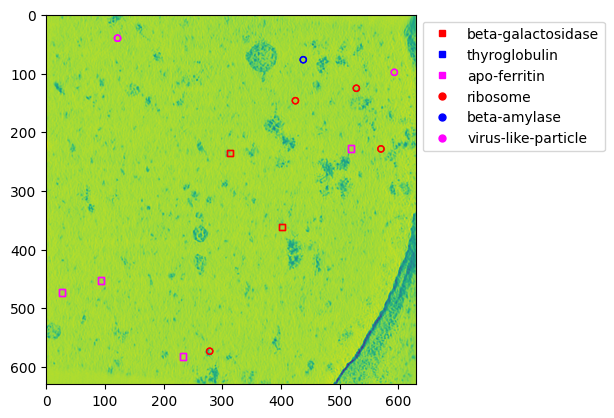

In [266]:
i = 91
print(hig_labels_list[i])
mark_particle_on_image(hig_res_dataset['TS_5_4'][i, :, :], hig_labels_list[i])

## Plotting

#### Plotting images of tomogram

60
61
62
63


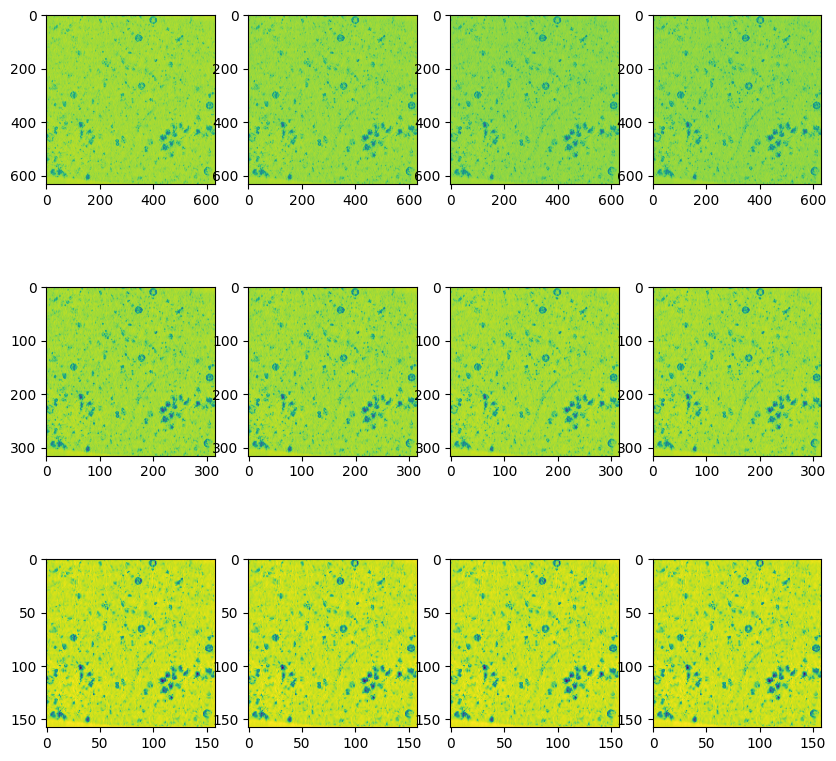

In [9]:
experiment_run = 'TS_86_3'
z1 = hig_res_dataset[experiment_run]
fig = plt.figure(figsize=(10,10))

start = 60
n_imgs = 4
for i in range(z1.shape[0]):
    if i < start:
        continue
    if i > start + n_imgs-1:
        break
    ax = plt.subplot(3, n_imgs, i-start+1)
    _ = plt.imshow(hig_res_dataset[experiment_run][i, :, :])
    # plt.colorbar()
    ax = plt.subplot(3, n_imgs, i-start+1+n_imgs)
    _ = plt.imshow(med_res_dataset[experiment_run][i//2, :, :])
    # plt.colorbar()
    ax = plt.subplot(3, n_imgs, i-start+1+n_imgs*2)
    _ = plt.imshow(low_res_dataset[experiment_run][i//4, :, :])
    # plt.colorbar()


#### Plotting 3d representation

In [6]:
# scans = np.array(low_res_dataset['TS_5_4'])
# norm = Normalize(vmin=scans.min(), vmax=scans.max())

# point_cloud = o3d.geometry.PointCloud()
# points = []
# colors = []
# c_values = [np.array(cm.viridis(scans[0][0][0])[:3])]
# for experiment_run in range(scans.shape[0]):
#     for x in range(scans.shape[1]):
#         for y in range(scans.shape[2]):
#             points.append(np.array((experiment_run, x, y)))
#             color = np.array(cm.viridis(norm(scans[experiment_run][x][y]))[:3])
#             colors.append(color)
# point_cloud.points = o3d.utility.Vector3dVector(points)
# point_cloud.colors = o3d.utility.Vector3dVector(colors)
# o3d.visualization.draw_geometries([point_cloud])

#### Plotting RGB channel for points

In [7]:
# fig = plt.figure(figsize=(10,10))
# ax = plt.subplot(3, 1, 1)
# ax.plot(np.arange(len(colors)), np.array(colors)[:, 0])
# ax = plt.subplot(3, 1, 2)
# ax.plot(np.arange(len(colors)), np.array(colors)[:, 1])
# ax = plt.subplot(3, 1, 3)
# ax.plot(np.arange(len(colors)), np.array(colors)[:, 2])

## Creating dataset

In [8]:
class CZII_Dataset(Dataset):
    def __init__(self, imgs, jsons):
        self.ys = []
        for json in jsons:
            target = {}
            target['boxes'] = self.json_extraxt_boxes(json=json)
            target['labels'] = self.json_extraxt_labels(json=json)
            self.ys.append(target)
        self.xs = list(imgs)

    def json_extraxt_boxes(self, json):
        print(json)
    
    def json_extraxt_labels(self, json):
        print(json)

    def __len__(self):
        return len(self.xs)
    
    def __getitem__(self, idx):
        y = self.ys.iloc[idx]
        x = torch.Tensor(np.array(self.xs.iloc[idx]))
        return x, y
